In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os, sys, time
import geopandas as gpd

REPO = Path(os.getcwd()).parent
DATA_ROOT = REPO.parent.parent / 'Data' / 'replication_package'
PLOT_ROOT = DATA_ROOT.parent.parent / 'Plots' / 'Regional'

sys.path.insert(0, os.path.join(REPO, 'Code', 'tools'))
import inequality_analyzers as ia

In [2]:
# Load CBOS data
cbos = pd.read_csv(DATA_ROOT / 'CBOS' / 'CBOS_survey.csv', low_memory=False)

# Load LIS Voiv
lis_voiv = pd.read_csv(DATA_ROOT / 'LIS' / 'LIS_Voiv.csv')
# Load LIS Groups
lis_groups = pd.read_csv(DATA_ROOT / 'LIS' / 'LIS_Groups.csv')

In [3]:
# We create relevant columns
cbos["H_total_income"] = cbos["income_hh_t_imputed"]        # Total household income: income per household member multiplied by household size
cbos["P_income"] = cbos["income_p_imputed"]

# Regional aspect:
# - 1990-1998: old voivodeships (49 units) -> location_old_L
# - 1999-2.2017: new voivodeships (16 units) -> location_new_L
# - 3.2017-12.2017: macroregions (6 units) -> macroregion

# Deflators (for base year in [1986, 1990, 2017, 2023]):
# - deflator_YYYY: average yearly deflator, with base year in YYYY.
# - deflator_YYYY_m: monthly deflator, with base year in January of YYYY.
relevant_check_columns = ['sex_L', 'age', 'educ_2000_L', 'household_size', 'weight_VOIV_NORM', 'income_hh', 'H_total_income']

In [4]:
# Load geometry for NEW voivodeships (16 units, 1999-2017)
region_gdf = gpd.read_file(DATA_ROOT / 'geometry' / 'geometry.gpkg', layer='new_voivodeships')

In [5]:
cbos

,Unnamed: 0,org_id,survey_file,survey_year,survey_month,age,year_born,sex,sex_L,city_size,...,deflator_1986,deflator_1986_m,deflator_1990,deflator_1990_m,deflator_2017,deflator_2017_m,deflator_2023,deflator_2023_m,H_total_income,P_income
0,0,1.0,CBOS_1_01_1990.sav,1990,1,33.0,1957.0,2.0,Kobieta,9.0,...,0.018994,0.028802,0.659450,1.00000,15.718490,23.835772,22.205643,33.672997,152.0,NaN
1,1,2.0,CBOS_1_01_1990.sav,1990,1,40.0,1950.0,2.0,Kobieta,9.0,...,0.018994,0.028802,0.659450,1.00000,15.718490,23.835772,22.205643,33.672997,80.0,NaN
2,2,3.0,CBOS_1_01_1990.sav,1990,1,58.0,1932.0,2.0,Kobieta,9.0,...,0.018994,0.028802,0.659450,1.00000,15.718490,23.835772,22.205643,33.672997,34.0,NaN
3,3,4.0,CBOS_1_01_1990.sav,1990,1,44.0,1946.0,1.0,Mężczyzna,9.0,...,0.018994,0.028802,0.659450,1.00000,15.718490,23.835772,22.205643,33.672997,150.0,NaN
4,7,8.0,CBOS_1_01_1990.sav,1990,1,64.0,1926.0,2.0,Kobieta,9.0,...,0.018994,0.028802,0.659450,1.00000,15.718490,23.835772,22.205643,33.672997,25.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355331,358520,921.0,CBOS_331_12_2017.sav,2017,12,60.0,1957.0,1.0,Mężczyzna,1.0,...,0.001202,0.001189,0.041738,0.04129,0.994852,0.984175,1.405436,1.390353,0.0,3088.6375
355332,358521,922.0,CBOS_331_12_2017.sav,2017,12,36.0,1981.0,1.0,Mężczyzna,1.0,...,0.001202,0.001189,0.041738,0.04129,0.994852,0.984175,1.405436,1.390353,6000.0,2600.0000
355333,358522,923.0,CBOS_331_12_2017.sav,2017,12,41.0,1976.0,1.0,Mężczyzna,5.0,...,0.001202,0.001189,0.041738,0.04129,0.994852,0.984175,1.405436,1.390353,2700.0,2500.0000
355334,358523,924.0,CBOS_331_12_2017.sav,2017,12,46.0,1971.0,2.0,Kobieta,5.0,...,0.001202,0.001189,0.041738,0.04129,0.994852,0.984175,1.405436,1.390353,6000.0,3500.0000


In [6]:
# Initialize analyzers
# CBOS: microdata analyzer with 1986 PLN deflation
cbos_a = ia.CBOSAnalyzer(cbos, 
                         income_col='H_total_income',
                         weight_col='weight_VOIV_h_NORM',
                         deflator_col='deflator_2023_m'
                         )

# LIS: pre-computed aggregates
lis_voiv_a = ia.LISAnalyzer(lis_voiv, income_type='hitotalnet', deflator_col='deflator_2023')
lis_groups_a = ia.LISAnalyzer(lis_groups, income_type='hitotalnet', deflator_col='deflator_2023')

# Quick summaries
print("CBOS:", cbos_a.summary())
print("LIS Voiv:", lis_voiv_a.summary())
print("LIS Groups:", lis_groups_a.summary())

CBOS: {'n_observations': 355336, 'year_range': (np.int64(1990), np.int64(2017)), 'n_years': 28, 'income_col': 'H_total_income', 'weight_col': 'weight_VOIV_h_NORM', 'deflator_col': 'deflator_2023_m', 'income_non_null': np.int64(352371), 'weight_non_null': np.int64(355336)}
LIS Voiv: {'income_type': 'hitotalnet', 'n_regions': 71, 'year_range': (np.int64(1986), np.int64(2023)), 'n_metrics': 31, 'available_metrics': ['N_total', 'Nw_total', 'mean', 'median', 'p10', 'p25', 'p75', 'p90', 'p99', 'p90p10', 'p90p50', 'p50p10', 'gini', 'theil', 'palma', 'N_Bottom_50', 'Nw_Bottom_50', 'Bottom_50', 'N_P50_90', 'Nw_P50_90', 'P50_90', 'N_Top_10', 'Nw_Top_10', 'Top_10', 'N_Top_1', 'Nw_Top_1', 'Top_1', 'share_Bottom_50', 'share_P50_90', 'share_Top_10', 'share_Top_1'], 'deflator': 'deflator_2023'}
LIS Groups: {'income_type': 'hitotalnet', 'n_regions': 141, 'year_range': (np.int64(1999), np.int64(2023)), 'n_metrics': 31, 'available_metrics': ['N_total', 'Nw_total', 'mean', 'median', 'p10', 'p25', 'p75', 

In [7]:
# Set up for plotting
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Params for clean and minimalistic plots
sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.figsize': (6,6),
    'font.size': 11.0,
    'font.family': 'serif',
    'font.serif': 'Palatino',
    'axes.titlesize': 'medium',
    'figure.titlesize': 'large',
    'legend.fontsize': 'medium',
    # dpi for high-res output
    'figure.dpi': 100,
    'savefig.dpi': 300,
    # Tight layout by default
    'figure.autolayout': True,
    'text.usetex': True,
    'text.latex.preamble': r"\usepackage[T1]{fontenc}\usepackage[utf8]{inputenc}\usepackage{amsmath}\usepackage{amssymb}\usepackage{siunitx}[=v2]",
})

COLORS = {
    'CBOS': ["#274690",  # deep sapphire
    "#3B7DD8",  # cornflower-ish
    "#2BB3C0",  # bright teal-cyan
    "#1F9A8A",  # sea-green teal
    "#6B57C9",  # indigo-violet
    "#A78FFF",  # soft lilac
    ],
    'LIS': ["#8B2E2E",  # deep brick
    "#B63E3E",  # warm berry
    "#E06B57",  # terra-cotta / coral
    "#C75B7C",  # dusty rose
    "#9A2442",  # cranberry
    "#5B1F2E",  # maroon
    ]
}

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_29505/3140688749.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


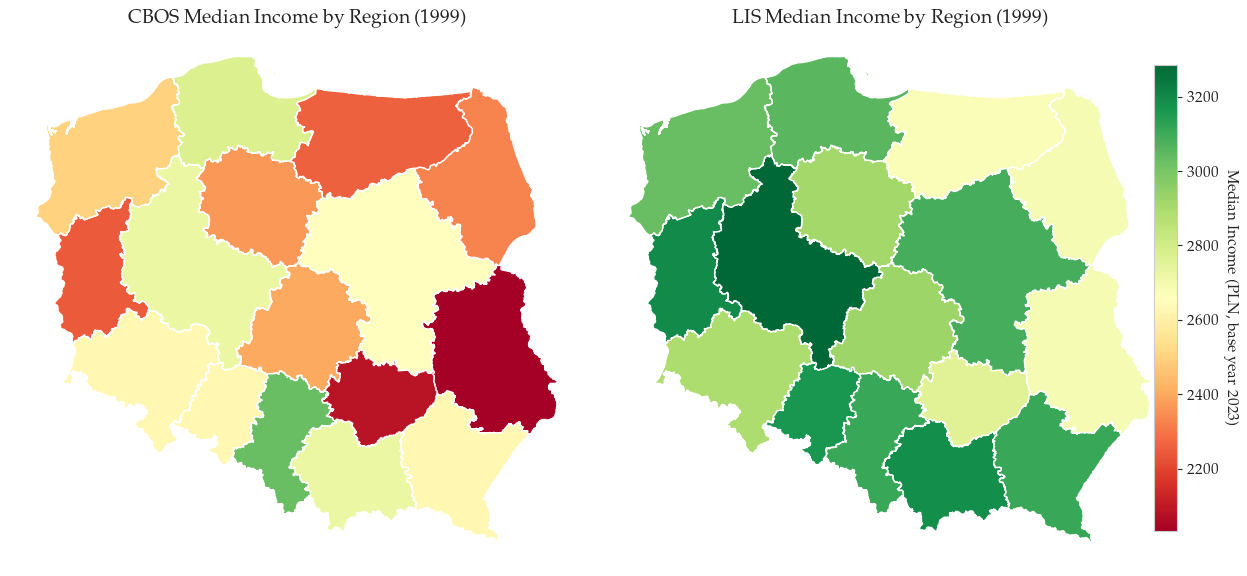

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_29505/3140688749.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


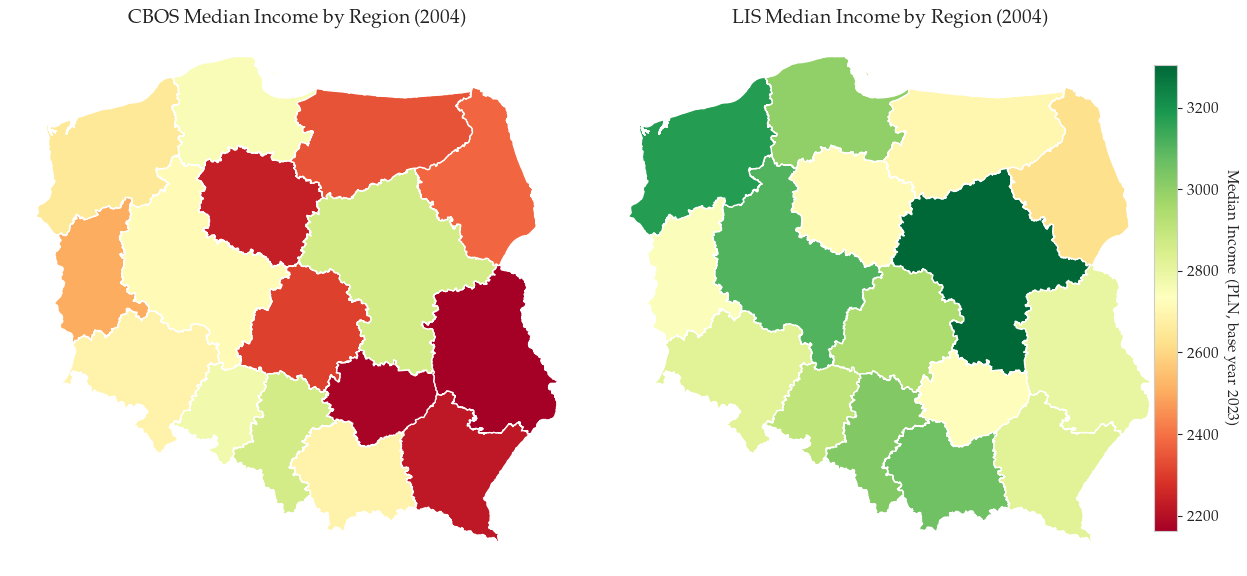

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_29505/3140688749.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


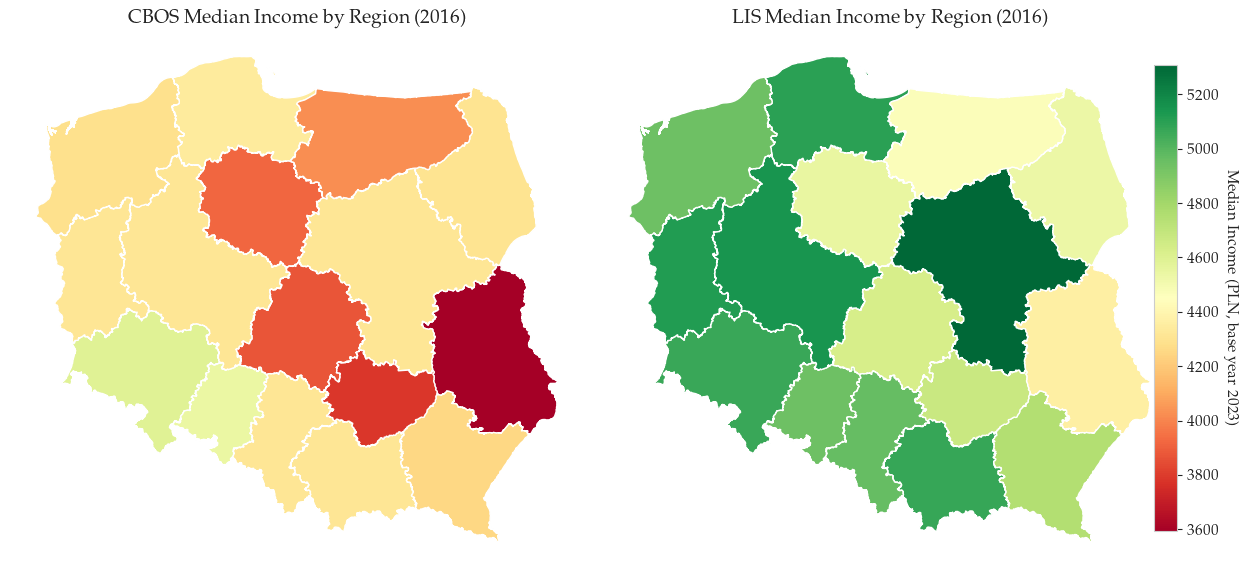

In [8]:
# ── Median income maps: 1999, 2004, 2016 — CBOS vs LIS side by side ─────────
YEARS = [1999, 2004, 2016]

for YEAR in YEARS:
    cbos_regional = cbos_a.regional_metrics(year=YEAR, region_col='location_new_L', region_id_col='teryt_id_VOIV')
    cbos_regional['region_id'] = cbos_regional['region_id'].str.zfill(7)
    lis_regional = lis_voiv_a.regional_panel(metrics=['median'], region_id_col='region_id')
    lis_regional = lis_regional[lis_regional['year'] == YEAR].copy()
    lis_regional['region_id'] = lis_regional['region_id'].astype(str).str.zfill(7)

    # Map values
    gdf = region_gdf.copy()
    gdf['cbos'] = gdf['teryt_id'].map(cbos_regional.set_index('region_id')['median'])
    gdf['lis'] = gdf['teryt_id'].map(lis_regional.set_index('region_id')['median'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    vmin = min(gdf['cbos'].min(), gdf['lis'].min())
    vmax = max(gdf['cbos'].max(), gdf['lis'].max())
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.RdYlGn
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

    gdf.plot(column='cbos', ax=ax1, legend=False, cmap=cmap, norm=norm)
    ax1.set_title(f'CBOS Median Income by Region ({YEAR})', fontsize=14)
    ax1.axis('off')

    gdf.plot(column='lis', ax=ax2, legend=False, cmap=cmap, norm=norm)
    ax2.set_title(f'LIS Median Income by Region ({YEAR})', fontsize=14)
    ax2.axis('off')

    cbar = fig.colorbar(sm, ax=[ax1, ax2], orientation='vertical', fraction=0.02, pad=0.01)
    cbar.set_label('Median Income (PLN, base year 2023)', rotation=270, labelpad=15)
    plt.tight_layout()
    plt.savefig(PLOT_ROOT / f'median_income_map_{YEAR}.png', bbox_inches='tight')
    plt.show()

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_29505/413191230.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


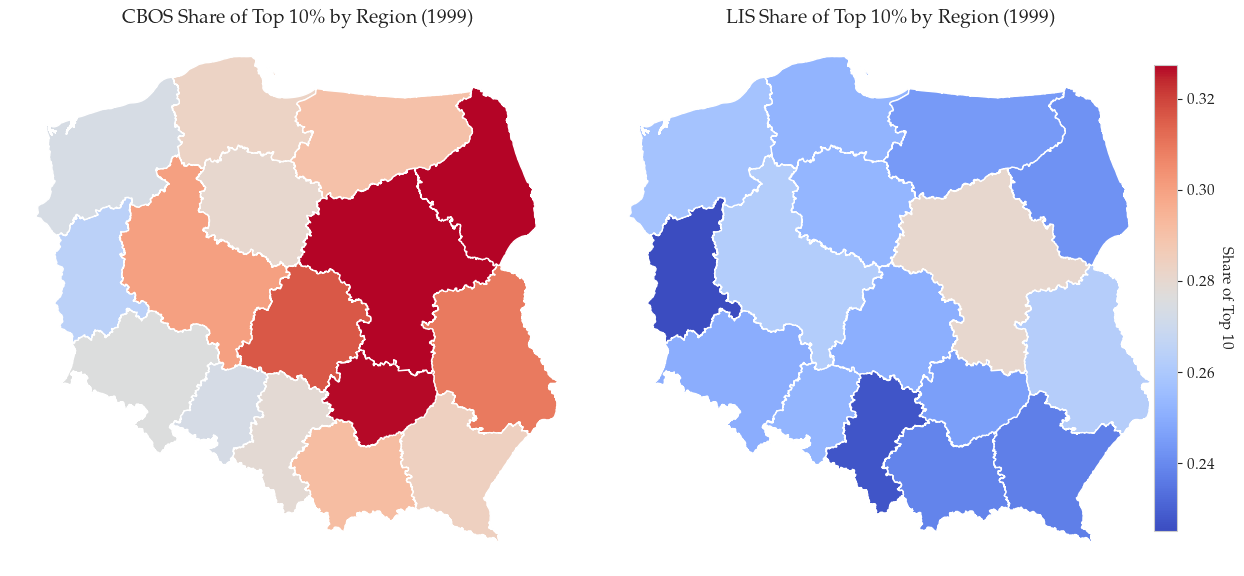

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_29505/413191230.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


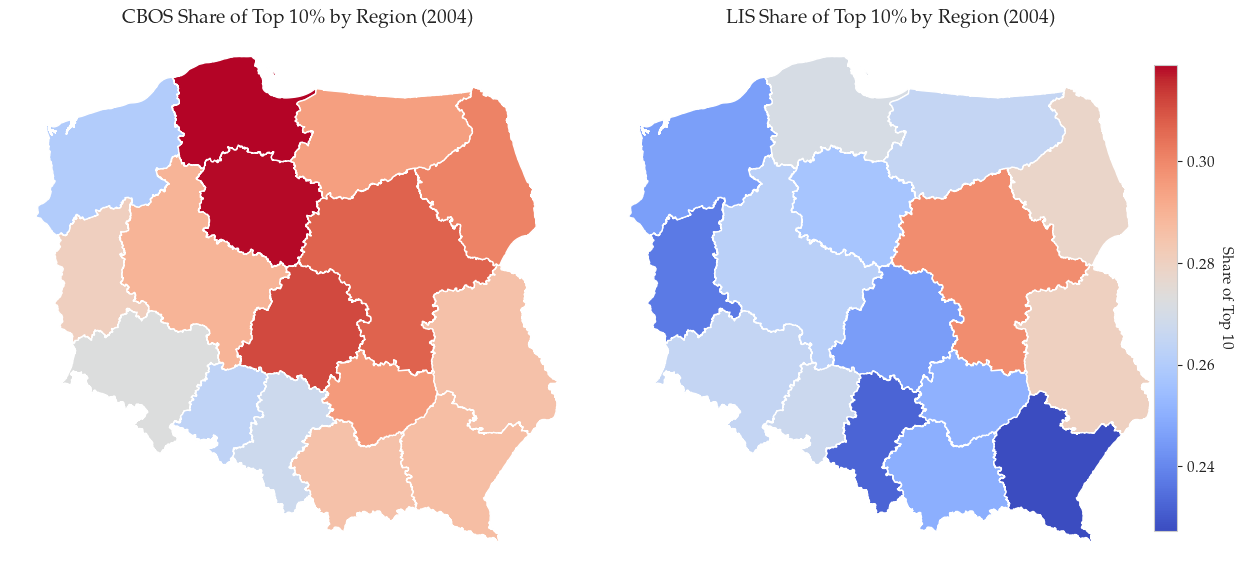

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_29505/413191230.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


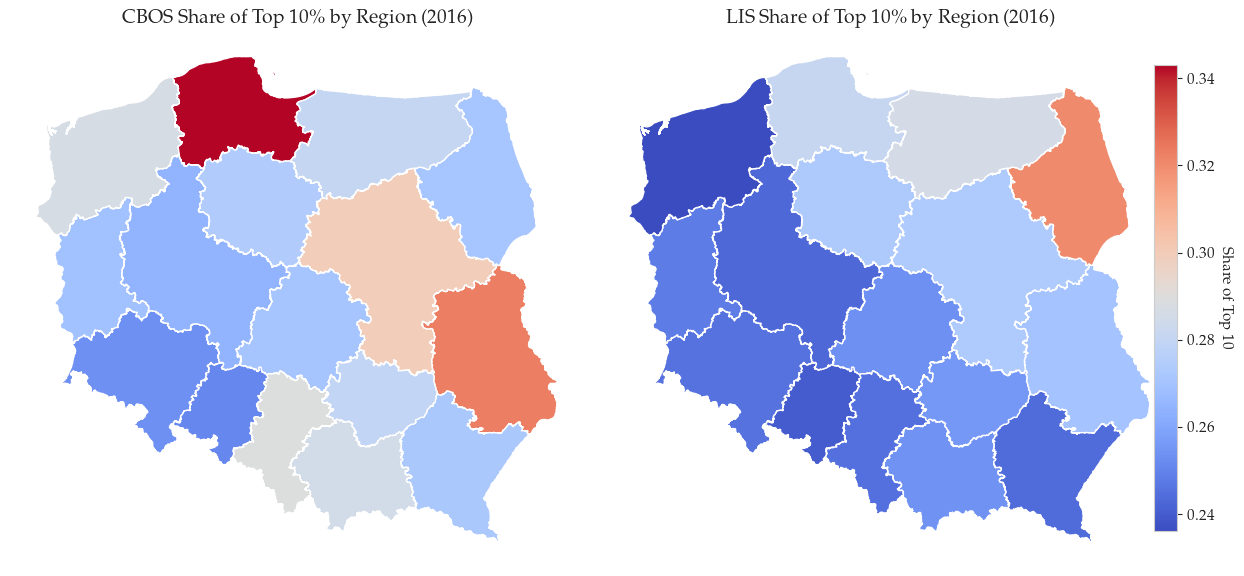

In [9]:
# ── Share Top 10% maps: 1999, 2004, 2016 — CBOS vs LIS side by side ─────────
YEARS = [1999, 2004, 2016]

for YEAR in YEARS:
    cbos_regional = cbos_a.regional_metrics(year=YEAR, region_col='location_new_L', region_id_col='teryt_id_VOIV')
    cbos_regional['region_id'] = cbos_regional['region_id'].str.zfill(7)
    lis_regional = lis_voiv_a.regional_panel(metrics=['share_Top_10'], region_id_col='region_id')
    lis_regional = lis_regional[lis_regional['year'] == YEAR].copy()
    lis_regional['region_id'] = lis_regional['region_id'].astype(str).str.zfill(7)

    gdf = region_gdf.copy()
    gdf['cbos'] = gdf['teryt_id'].map(cbos_regional.set_index('region_id')['share_Top_10'])
    gdf['lis'] = gdf['teryt_id'].map(lis_regional.set_index('region_id')['share_Top_10'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    vmin = min(gdf['cbos'].min(), gdf['lis'].min())
    vmax = max(gdf['cbos'].max(), gdf['lis'].max())
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.coolwarm
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

    gdf.plot(column='cbos', ax=ax1, legend=False, cmap=cmap, norm=norm)
    ax1.set_title(f'CBOS Share of Top 10\\% by Region ({YEAR})', fontsize=14)
    ax1.axis('off')

    gdf.plot(column='lis', ax=ax2, legend=False, cmap=cmap, norm=norm)
    ax2.set_title(f'LIS Share of Top 10\\% by Region ({YEAR})', fontsize=14)
    ax2.axis('off')

    cbar = fig.colorbar(sm, ax=[ax1, ax2], orientation='vertical', fraction=0.02, pad=0.01)
    cbar.set_label('Share of Top 10%', rotation=270, labelpad=15)
    plt.tight_layout()
    plt.savefig(PLOT_ROOT / f'share_top_10_map_{YEAR}.png', bbox_inches='tight')
    plt.show()

In [10]:
# ── Theil between/within decomposition (new voivodeships, 1999-2017) ─────────
theil_ts = cbos_a.regional_theil_timeseries('location_new_L', year_range=(1999, 2017))
display(theil_ts[['year', 'total_theil', 'between', 'within', 'between_pct', 'within_pct']].round(4))

,year,total_theil,between,within,between_pct,within_pct
0,1999,0.2704,0.0048,0.2656,1.7767,98.2233
1,2000,0.2631,0.0038,0.2593,1.4608,98.5392
2,2001,0.2686,0.0039,0.2647,1.4496,98.5504
3,2002,0.2846,0.0035,0.2811,1.2141,98.7859
4,2003,0.5606,0.0268,0.5338,4.7805,95.2195
5,2004,0.2634,0.0042,0.2592,1.6003,98.3997
6,2005,0.2861,0.0032,0.2830,1.1056,98.8944
7,2006,0.3681,0.0050,0.3631,1.3607,98.6393
8,2007,0.4888,0.0088,0.4800,1.8044,98.1956
9,2008,0.3664,0.0038,0.3626,1.0369,98.9631


In [11]:
# ── Theil group contributions: which voivodeships drive total inequality? ─────
# Reload module to pick up the new methods
import importlib; importlib.reload(ia)

# Re-initialize analyzers after reload
cbos_a = ia.CBOSAnalyzer(cbos, income_col='H_total_income',
                         weight_col='weight_VOIV_h_NORM',
                         deflator_col='deflator_2023_m')
lis_voiv_a = ia.LISAnalyzer(lis_voiv, income_type='hitotalnet', deflator_col='deflator_2023')

# CBOS: per-voivodeship contributions for 2004 (with region_id for map merging)
cbos_contrib_2004 = cbos_a.theil_contributions(2004, 'location_new_L',
                                                region_id_col='teryt_id_VOIV')
print("=== CBOS: Voivodeship contributions to total Theil T (2004) ===")
display(cbos_contrib_2004.sort_values('total_contribution', ascending=False)
        [['group', 'region_id', 'income_share', 'between_contribution', 'within_contribution',
          'total_contribution', 'contribution_pct']].round(4))

# CBOS: contribution timeseries (1999-2017, with region_id)
cbos_contrib_ts = cbos_a.theil_contribution_timeseries('location_new_L',
                                                        year_range=(1999, 2017),
                                                        region_id_col='teryt_id_VOIV')
print(f"\nPanel shape: {cbos_contrib_ts.shape}  |  Groups: {cbos_contrib_ts['group'].nunique()}  |  Years: {sorted(cbos_contrib_ts['year'].unique())}")

=== CBOS: Voivodeship contributions to total Theil T (2004) ===


,group,region_id,income_share,between_contribution,within_contribution,total_contribution,contribution_pct
4,mazowieckie,1400000,0.1656,0.0233,0.0487,0.0720,27.3238
14,śląskie,2400000,0.1378,0.0028,0.0323,0.0350,13.2974
11,wielkopolskie,3000000,0.0847,0.0037,0.0221,0.0257,9.7698
9,pomorskie,2200000,0.0625,0.0058,0.0188,0.0246,9.3363
5,małopolskie,1200000,0.0817,0.0027,0.0216,0.0243,9.2270
0,dolnośląskie,200000,0.0791,-0.0018,0.0179,0.0161,6.1146
1,kujawsko-pomorskie,400000,0.0502,-0.0024,0.0158,0.0134,5.1046
13,łódzkie,1000000,0.0637,-0.0073,0.0183,0.0110,4.1669
12,zachodniopomorskie,3200000,0.0459,-0.0008,0.0096,0.0089,3.3689
8,podlaskie,2000000,0.0299,0.0008,0.0075,0.0083,3.1593



Panel shape: (310, 11)  |  Groups: 22  |  Years: [np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017)]


In [12]:
# ── LIS: per-voivodeship Theil contributions ─────────────────────────────────
lis_contrib_2004 = lis_voiv_a.theil_contributions(2004, region_id_col='region_id')
print("=== LIS: Voivodeship contributions to total Theil T (2004) ===")
display(lis_contrib_2004.sort_values('total_contribution', ascending=False)
        [['group', 'region_id', 'income_share', 'between_contribution', 'within_contribution',
          'total_contribution', 'contribution_pct']].round(4))

# LIS: contribution timeseries (1999-2017, with region_id)
lis_contrib_ts = lis_voiv_a.theil_contribution_timeseries(
    year_range=(1999, 2017), region_id_col='region_id')
print(f"\nPanel shape: {lis_contrib_ts.shape}  |  Groups: {lis_contrib_ts['group'].nunique()}  |  Years: {sorted(lis_contrib_ts['year'].unique())}")

=== LIS: Voivodeship contributions to total Theil T (2004) ===


,group,region_id,income_share,between_contribution,within_contribution,total_contribution,contribution_pct
6,Mazowieckie,1400000,0.1700,0.0285,0.0460,0.0745,34.8087
14,Wielkopolskie,3000000,0.0862,0.0049,0.0175,0.0224,10.4549
0,Dolnoslaskie,200000,0.0778,-0.0021,0.0187,0.0166,7.7552
10,Pomorskie,2200000,0.0596,0.0024,0.0137,0.0161,7.5439
5,Malopolskie,1200000,0.0794,0.0009,0.0152,0.0161,7.4980
11,Slaskie,2400000,0.1267,-0.0053,0.0207,0.0154,7.1823
2,Lodzkie,1000000,0.0699,-0.0029,0.0127,0.0099,4.6181
3,Lubelskie,600000,0.0529,-0.0026,0.0124,0.0098,4.5821
15,Zachodniopomorskie,3200000,0.0466,0.0007,0.0082,0.0089,4.1465
7,Opolskie,1600000,0.0271,-0.0003,0.0060,0.0057,2.6493



Panel shape: (240, 11)  |  Groups: 16  |  Years: [np.int64(1999), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017)]


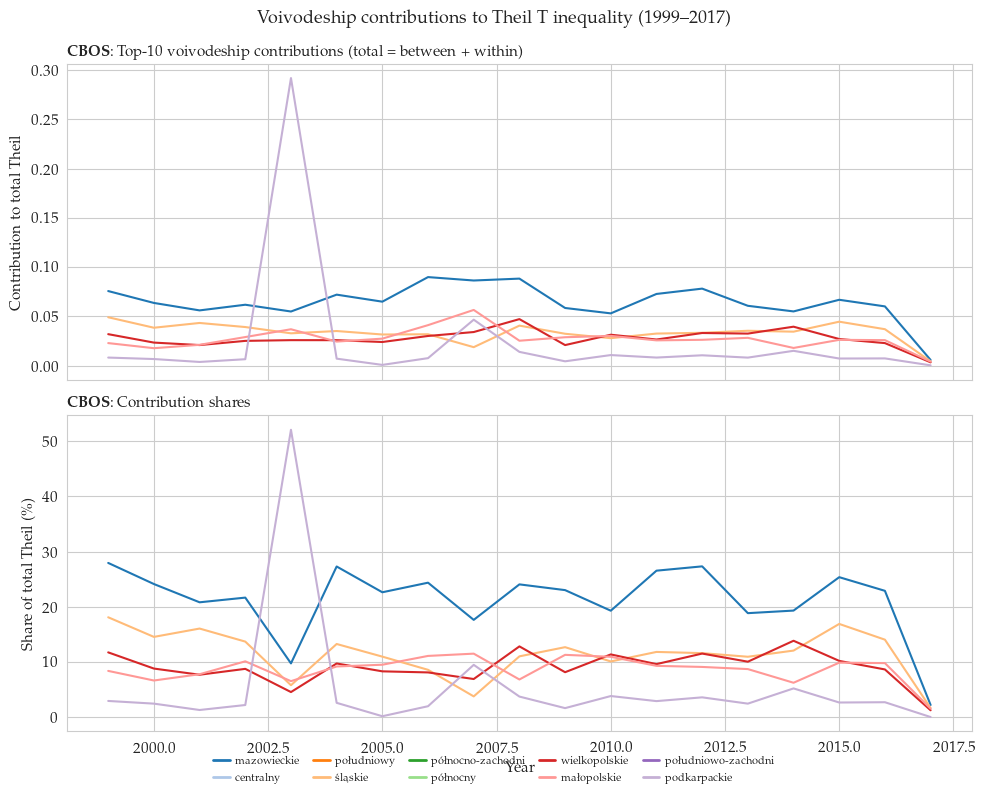

In [13]:
from matplotlib.lines import Line2D

# ── Plot: Top-10 voivodeships by average contribution (CBOS, 1999-2017) ──────
avg_contrib = (cbos_contrib_ts.groupby('group')['total_contribution']
               .mean().sort_values(ascending=False))
top10 = avg_contrib.head(10).index.tolist()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.subplots_adjust(hspace=0.08, bottom=0.18)
cmap = plt.cm.tab20
colors = [cmap(i) for i in range(10)]

# --- Top panel: total contribution for top-10 ---
for i, grp in enumerate(top10):
    d = cbos_contrib_ts[cbos_contrib_ts['group'] == grp].sort_values('year')
    ax1.plot(d['year'], d['total_contribution'], color=colors[i], lw=1.5)
ax1.set_ylabel('Contribution to total Theil')
ax1.set_title(r'\textbf{CBOS}: Top-10 voivodeship contributions (total = between + within)', fontsize=11, loc='left')

# --- Bottom panel: contribution_pct over time ---
for i, grp in enumerate(top10):
    d = cbos_contrib_ts[cbos_contrib_ts['group'] == grp].sort_values('year')
    ax2.plot(d['year'], d['contribution_pct'], color=colors[i], lw=1.5)
ax2.set_ylabel(r'Share of total Theil (\%)')
ax2.set_xlabel('Year')
ax2.set_title(r'\textbf{CBOS}: Contribution shares', fontsize=11, loc='left')

# Short labels for legend
short_labels = [g[:20] for g in top10]
_h = [Line2D([0],[0], color=colors[i], lw=2) for i in range(10)]
fig.legend(_h, short_labels, loc='lower center', ncol=5,
           bbox_to_anchor=(0.5, 0.0), frameon=False,
           handlelength=1.5, handletextpad=0.5, columnspacing=1.2, fontsize=8)
fig.suptitle('Voivodeship contributions to Theil T inequality (1999--2017)', fontsize=13)
#plt.savefig(PLOT_ROOT / "theil_contributions_top10_voiv_1999_2017.png", bbox_inches='tight')
plt.show()

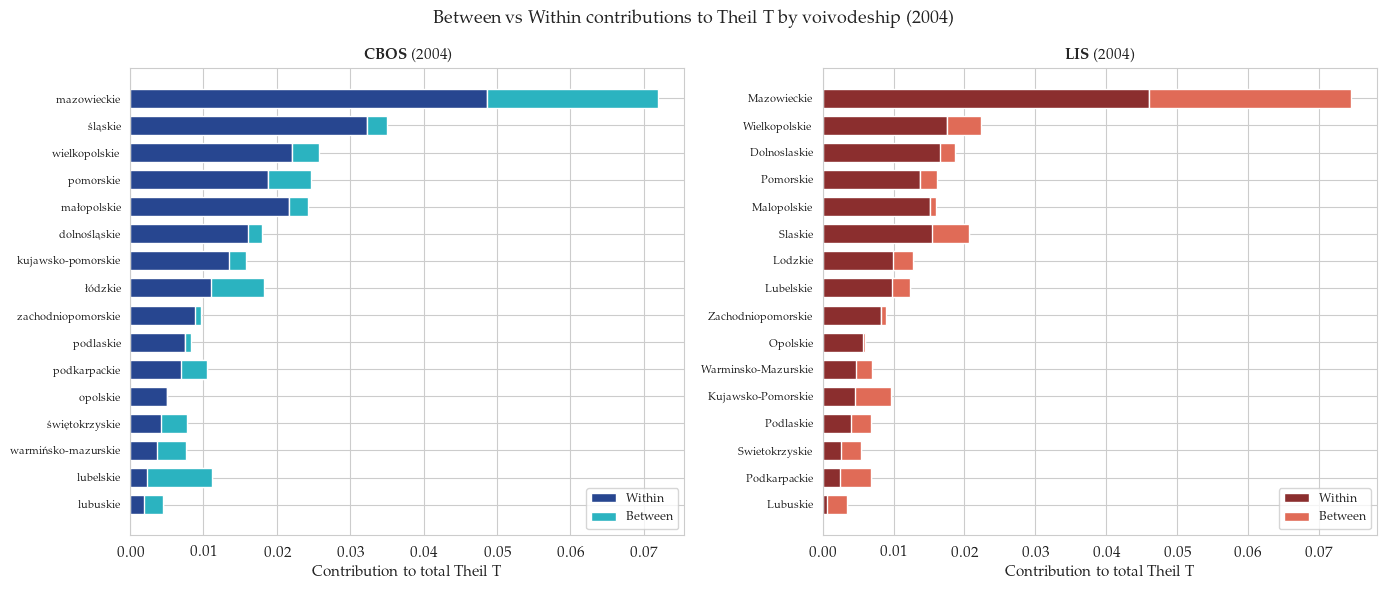

In [14]:
# ── Stacked bar: Between vs Within contribution by voivodeship (2004) ────────
# All 16 voivodeships
cbos_2004 = cbos_contrib_2004.sort_values('total_contribution', ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.subplots_adjust(wspace=0.45)

# CBOS
ax1.barh(range(len(cbos_2004)), cbos_2004['within_contribution'].values,
         color=COLORS['CBOS'][0], label='Within', height=0.7)
ax1.barh(range(len(cbos_2004)), cbos_2004['between_contribution'].values,
         left=cbos_2004['within_contribution'].values,
         color=COLORS['CBOS'][2], label='Between', height=0.7)
ax1.set_yticks(range(len(cbos_2004)))
ax1.set_yticklabels(cbos_2004['group'].values, fontsize=8)
ax1.set_xlabel('Contribution to total Theil T')
ax1.set_title(r'\textbf{CBOS} (2004)', fontsize=11)
ax1.legend(fontsize=9)

# LIS (same year)
if not lis_contrib_2004.empty:
    lis_2004 = lis_contrib_2004.sort_values('total_contribution', ascending=True)
    ax2.barh(range(len(lis_2004)), lis_2004['within_contribution'].values,
             color=COLORS['LIS'][0], label='Within', height=0.7)
    ax2.barh(range(len(lis_2004)), lis_2004['between_contribution'].values,
             left=lis_2004['within_contribution'].values,
             color=COLORS['LIS'][2], label='Between', height=0.7)
    ax2.set_yticks(range(len(lis_2004)))
    ax2.set_yticklabels(lis_2004['group'].values, fontsize=8)
    ax2.set_xlabel('Contribution to total Theil T')
    ax2.set_title(r'\textbf{LIS} (2004)', fontsize=11)
    ax2.legend(fontsize=9)

fig.suptitle('Between vs Within contributions to Theil T by voivodeship (2004)', fontsize=13)
plt.savefig(PLOT_ROOT / "theil_between_within_bar_voiv_2004.png", bbox_inches='tight')
plt.show()

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_29505/3661180266.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_map = plt.cm.get_cmap(cmap_name)
/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_29505/3661180266.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_map = plt.cm.get_cmap(cmap_name)
/Users/jedrek/miniforge3/envs/py313/lib/python3.13/site-packages/geopandas/plotting.py:950: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  ax.figure.canvas.draw_idle()
/Users/jedrek/miniforge3/envs/py313/lib/python3.13/site-packages/geopandas

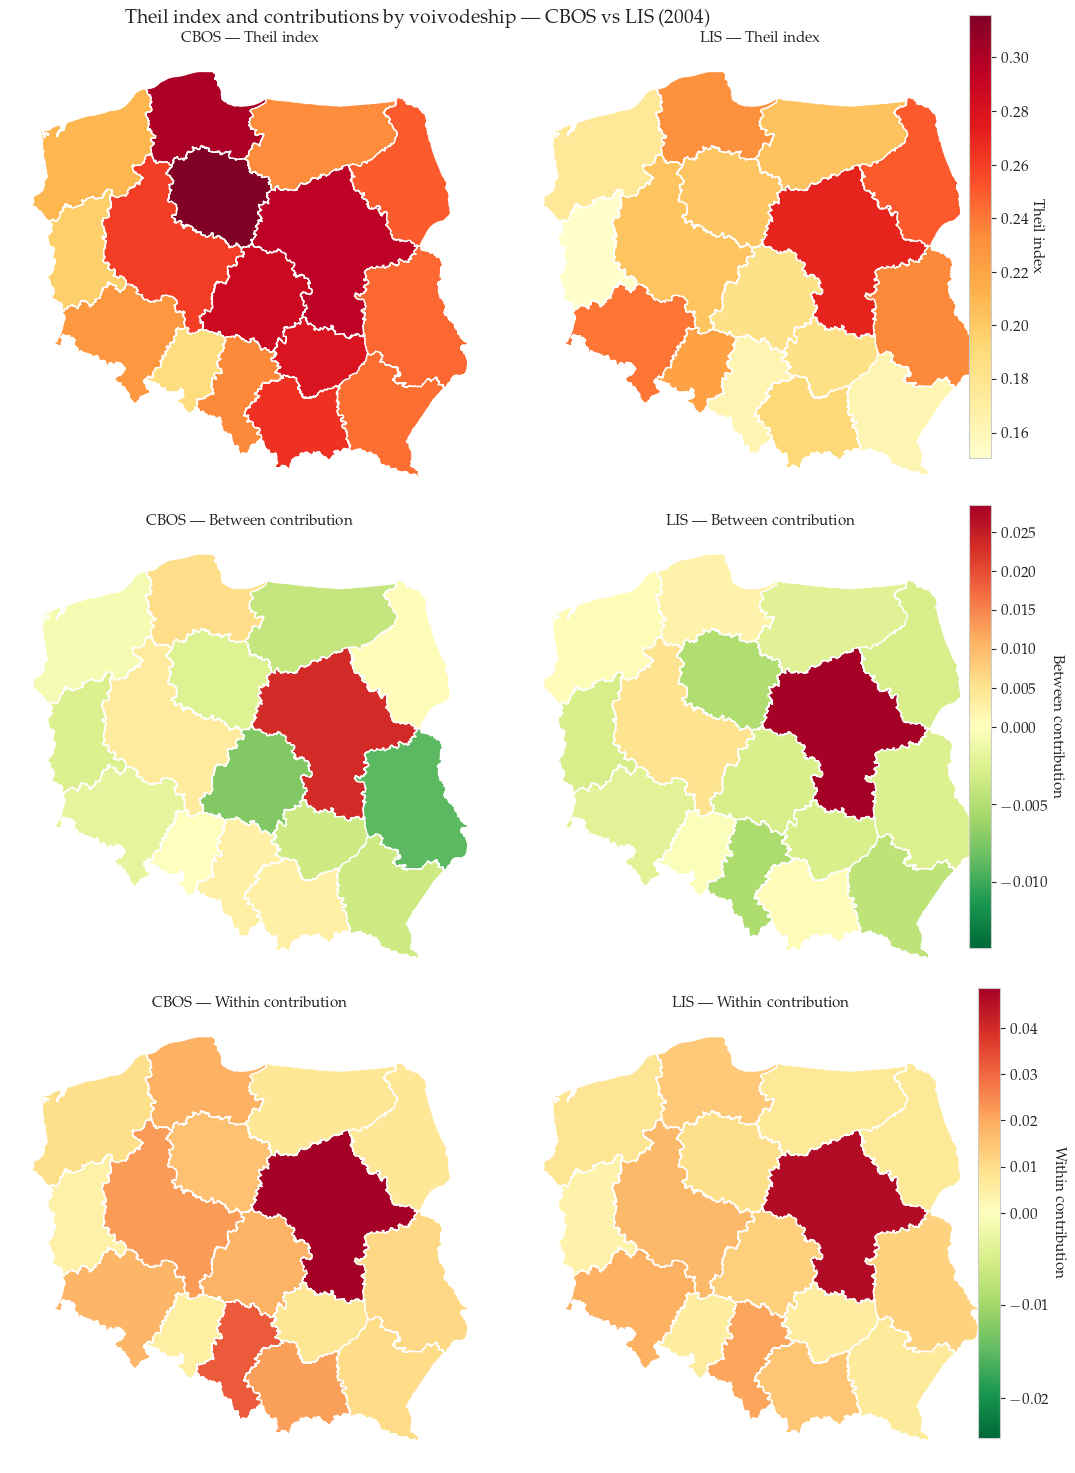

In [15]:
# ── Map: Theil index & contributions — CBOS vs LIS side by side (2004) ───────
YEAR = 2004

# CBOS: regional metrics for Theil index per voivodeship
cbos_reg = cbos_a.regional_metrics(YEAR, region_col='location_new_L', region_id_col='teryt_id_VOIV')
cbos_reg['region_id'] = cbos_reg['region_id'].str.zfill(7)
# CBOS contributions (region_id already populated via region_id_col)
cbos_ctr = cbos_a.theil_contributions(YEAR, 'location_new_L', region_id_col='teryt_id_VOIV')
cbos_ctr['region_id'] = cbos_ctr['region_id'].str.zfill(7)
# LIS: regional panel for Theil index per voivodeship
lis_reg = lis_voiv_a.regional_panel(metrics=['theil'], region_id_col='region_id')
lis_reg = lis_reg[lis_reg['year'] == YEAR].copy()
lis_reg['region_id'] = lis_reg['region_id'].astype(str).str.zfill(7)
# LIS contributions
lis_ctr = lis_voiv_a.theil_contributions(YEAR, region_id_col='region_id')
lis_ctr['region_id'] = lis_ctr['region_id'].astype(str).str.zfill(7)

# Row definitions: (cbos_data, cbos_col, lis_data, lis_col, label, cmap, diverging)
panel_rows = [
    (cbos_reg, 'theil',                lis_reg, 'theil',                'Theil index',            'YlOrRd',    False),
    (cbos_ctr, 'between_contribution', lis_ctr, 'between_contribution', 'Between contribution',   'RdYlGn_r',  True),
    (cbos_ctr, 'within_contribution',  lis_ctr, 'within_contribution',  'Within contribution',    'RdYlGn_r',  True),
]

fig, axes = plt.subplots(len(panel_rows), 2, figsize=(12, 5 * len(panel_rows)))
fig.subplots_adjust(hspace=0.25, wspace=0.05)

for row, (c_data, c_col, l_data, l_col, label, cmap_name, diverging) in enumerate(panel_rows):
    # Build value maps
    c_id_col = 'region_id'
    c_vals = c_data.set_index(c_id_col)[c_col]
    l_vals = l_data.set_index('region_id')[l_col]
    all_vals = pd.concat([c_vals, l_vals]).dropna()

    if diverging:
        vabs = max(abs(all_vals.min()), abs(all_vals.max()))
        norm = mpl.colors.TwoSlopeNorm(vmin=-vabs * 0.5, vcenter=0, vmax=vabs)
    else:
        norm = mpl.colors.Normalize(vmin=all_vals.min(), vmax=all_vals.max())
    cmap_map = plt.cm.get_cmap(cmap_name)

    # CBOS (left)
    gdf_c = region_gdf.copy()
    gdf_c['value'] = gdf_c['teryt_id'].map(c_vals)
    gdf_c.plot(column='value', ax=axes[row, 0], legend=False, cmap=cmap_map, norm=norm)
    axes[row, 0].set_title(f'CBOS — {label}', fontsize=11)
    axes[row, 0].axis('off')

    # LIS (right)
    gdf_l = region_gdf.copy()
    gdf_l['value'] = gdf_l['teryt_id'].map(l_vals)
    gdf_l.plot(column='value', ax=axes[row, 1], legend=False, cmap=cmap_map, norm=norm)
    axes[row, 1].set_title(f'LIS — {label}', fontsize=11)
    axes[row, 1].axis('off')

    # shared colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap_map, norm=norm)
    cbar = fig.colorbar(sm, ax=axes[row, :].tolist(), orientation='vertical',
                        fraction=0.02, pad=0.01)
    cbar.set_label(label, rotation=270, labelpad=12)

fig.suptitle(f'Theil index and contributions by voivodeship — CBOS vs LIS ({YEAR})', fontsize=14)
plt.savefig(PLOT_ROOT / f"theil_contributions_map_cbos_vs_lis_{YEAR}.png", bbox_inches='tight')
plt.show()

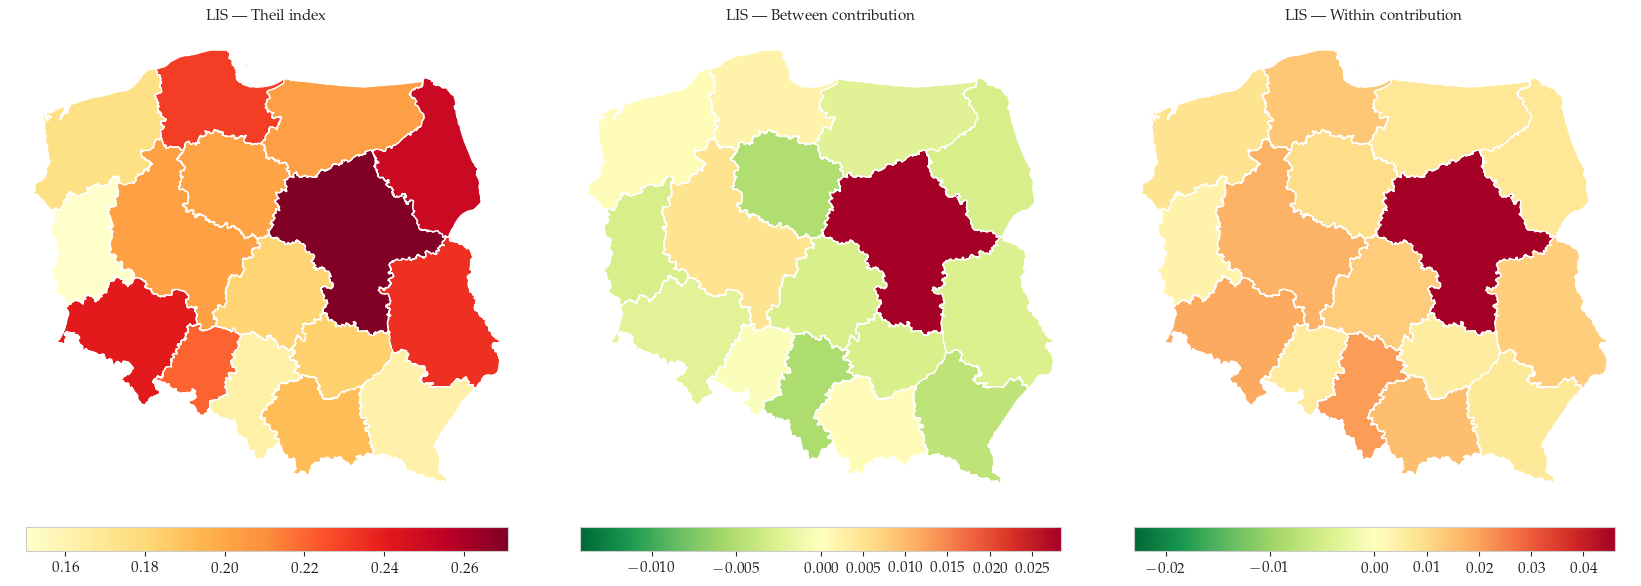

In [16]:
# ── Map: Theil index & contributions — LIS only (2004) ───────────────────────
YEAR = 2004

# LIS: regional panel for Theil index per voivodeship
lis_reg = lis_voiv_a.regional_panel(metrics=['theil'], region_id_col='region_id')
lis_reg = lis_reg[lis_reg['year'] == YEAR].copy()
lis_reg['region_id'] = lis_reg['region_id'].astype(str).str.zfill(7)
# LIS contributions
lis_ctr = lis_voiv_a.theil_contributions(YEAR, region_id_col='region_id')
lis_ctr['region_id'] = lis_ctr['region_id'].astype(str).str.zfill(7)

# Plot definitions: (data, col, label, cmap, diverging)
plot_defs = [
    (lis_reg, 'theil',                'Theil index',          'YlOrRd',   False),
    (lis_ctr, 'between_contribution', 'Between contribution', 'RdYlGn_r', True),
    (lis_ctr, 'within_contribution',  'Within contribution',  'RdYlGn_r', True),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.subplots_adjust(wspace=0.05)

for col, (data, val_col, label, cmap_name, diverging) in enumerate(plot_defs):
    vals = data.set_index('region_id')[val_col]

    if diverging:
        vabs = max(abs(vals.min()), abs(vals.max()))
        norm = mpl.colors.TwoSlopeNorm(vmin=-vabs * 0.5, vcenter=0, vmax=vabs)
    else:
        norm = mpl.colors.Normalize(vmin=vals.min(), vmax=vals.max())
    cmap_map = mpl.colormaps[cmap_name]

    gdf = region_gdf.copy()
    gdf['value'] = gdf['teryt_id'].map(vals)
    gdf.plot(column='value', ax=axes[col], legend=False, cmap=cmap_map, norm=norm)
    axes[col].set_title(f'LIS — {label}', fontsize=11)
    axes[col].axis('off')

    sm = plt.cm.ScalarMappable(cmap=cmap_map, norm=norm)
    fig.colorbar(sm, ax=axes[col], orientation='horizontal', fraction=0.046, pad=0.04)

plt.savefig(PLOT_ROOT / f"theil_contributions_map_lis_{YEAR}.png", bbox_inches='tight')
plt.show()

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_29505/1444952751.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_map = plt.cm.get_cmap(cmap_name)
/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_29505/1444952751.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_map = plt.cm.get_cmap(cmap_name)
/Users/jedrek/miniforge3/envs/py313/lib/python3.13/site-packages/geopandas/plotting.py:950: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  ax.figure.canvas.draw_idle()
/Users/jedrek/miniforge3/envs/py313/lib/python3.13/site-packages/geopandas

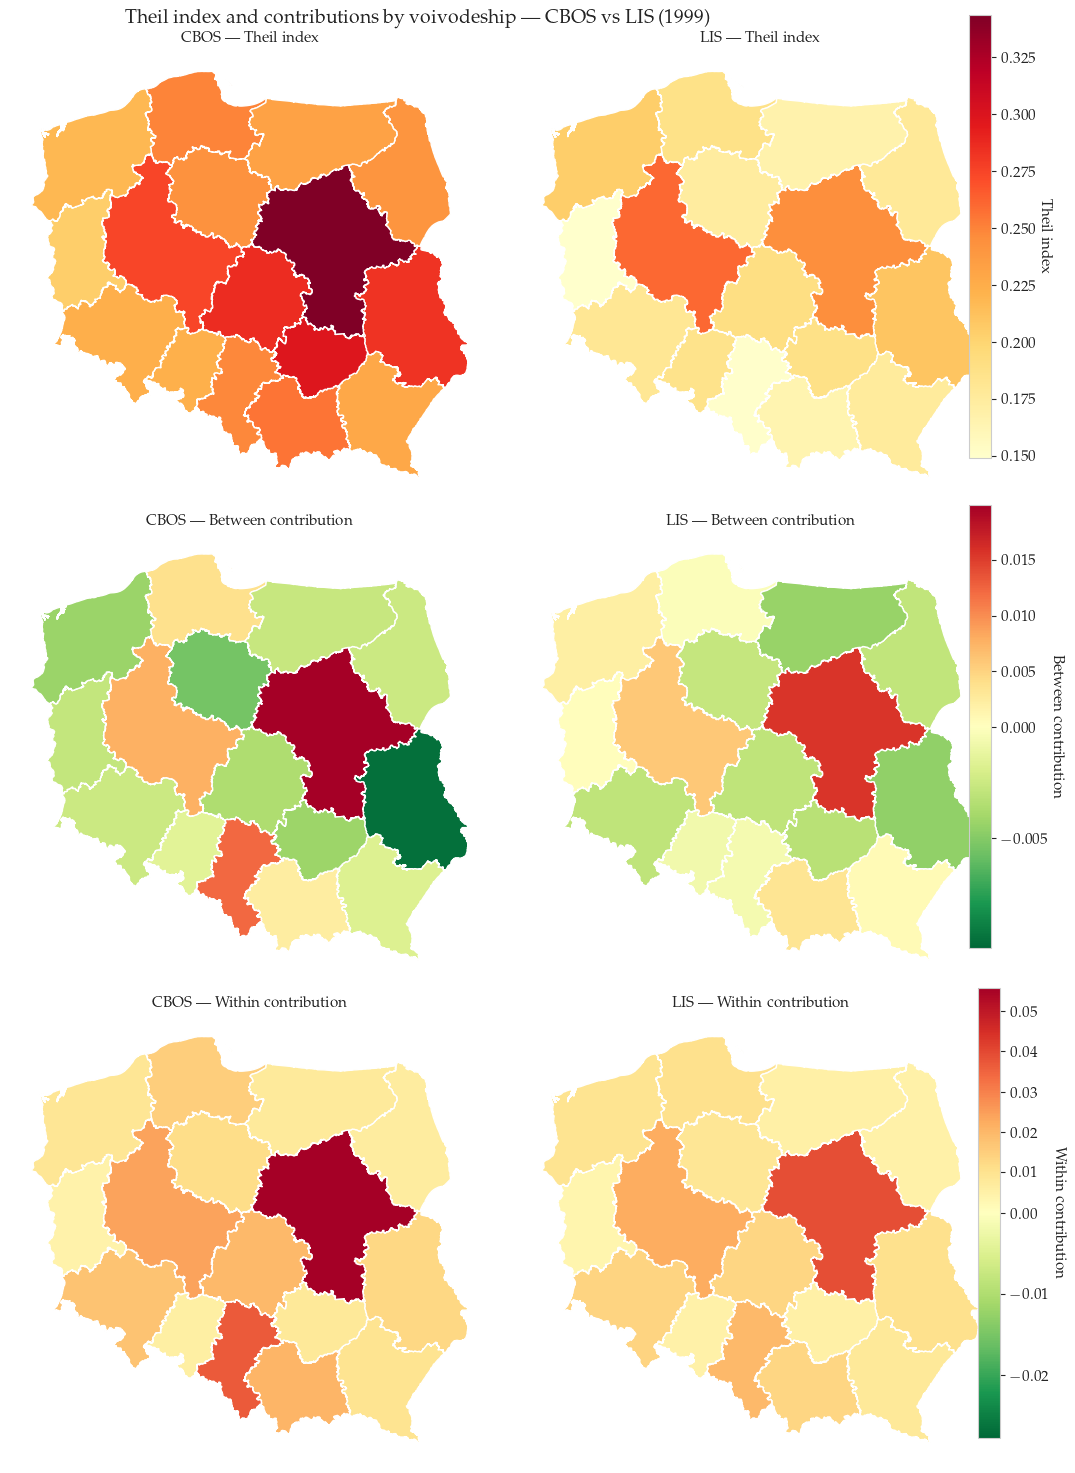

In [17]:
# ── Map: Theil index & contributions — CBOS vs LIS side by side (2004) ───────
YEAR = 1999

# CBOS: regional metrics for Theil index per voivodeship
cbos_reg = cbos_a.regional_metrics(YEAR, region_col='location_new_L', region_id_col='teryt_id_VOIV')
cbos_reg['region_id'] = cbos_reg['region_id'].str.zfill(7)
# CBOS contributions (region_id already populated via region_id_col)
cbos_ctr = cbos_a.theil_contributions(YEAR, 'location_new_L', region_id_col='teryt_id_VOIV')
cbos_ctr['region_id'] = cbos_ctr['region_id'].str.zfill(7)
# LIS: regional panel for Theil index per voivodeship
lis_reg = lis_voiv_a.regional_panel(metrics=['theil'], region_id_col='region_id')
lis_reg = lis_reg[lis_reg['year'] == YEAR].copy()
lis_reg['region_id'] = lis_reg['region_id'].astype(str).str.zfill(7)
# LIS contributions
lis_ctr = lis_voiv_a.theil_contributions(YEAR, region_id_col='region_id')
lis_ctr['region_id'] = lis_ctr['region_id'].astype(str).str.zfill(7)

# Row definitions: (cbos_data, cbos_col, lis_data, lis_col, label, cmap, diverging)
panel_rows = [
    (cbos_reg, 'theil',                lis_reg, 'theil',                'Theil index',            'YlOrRd',    False),
    (cbos_ctr, 'between_contribution', lis_ctr, 'between_contribution', 'Between contribution',   'RdYlGn_r',  True),
    (cbos_ctr, 'within_contribution',  lis_ctr, 'within_contribution',  'Within contribution',    'RdYlGn_r',  True),
]

fig, axes = plt.subplots(len(panel_rows), 2, figsize=(12, 5 * len(panel_rows)))
fig.subplots_adjust(hspace=0.25, wspace=0.05)

for row, (c_data, c_col, l_data, l_col, label, cmap_name, diverging) in enumerate(panel_rows):
    # Build value maps
    c_id_col = 'region_id'
    c_vals = c_data.set_index(c_id_col)[c_col]
    l_vals = l_data.set_index('region_id')[l_col]
    all_vals = pd.concat([c_vals, l_vals]).dropna()

    if diverging:
        vabs = max(abs(all_vals.min()), abs(all_vals.max()))
        norm = mpl.colors.TwoSlopeNorm(vmin=-vabs * 0.5, vcenter=0, vmax=vabs)
    else:
        norm = mpl.colors.Normalize(vmin=all_vals.min(), vmax=all_vals.max())
    cmap_map = plt.cm.get_cmap(cmap_name)

    # CBOS (left)
    gdf_c = region_gdf.copy()
    gdf_c['value'] = gdf_c['teryt_id'].map(c_vals)
    gdf_c.plot(column='value', ax=axes[row, 0], legend=False, cmap=cmap_map, norm=norm)
    axes[row, 0].set_title(f'CBOS — {label}', fontsize=11)
    axes[row, 0].axis('off')

    # LIS (right)
    gdf_l = region_gdf.copy()
    gdf_l['value'] = gdf_l['teryt_id'].map(l_vals)
    gdf_l.plot(column='value', ax=axes[row, 1], legend=False, cmap=cmap_map, norm=norm)
    axes[row, 1].set_title(f'LIS — {label}', fontsize=11)
    axes[row, 1].axis('off')

    # shared colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap_map, norm=norm)
    cbar = fig.colorbar(sm, ax=axes[row, :].tolist(), orientation='vertical',
                        fraction=0.02, pad=0.01)
    cbar.set_label(label, rotation=270, labelpad=12)

fig.suptitle(f'Theil index and contributions by voivodeship — CBOS vs LIS ({YEAR})', fontsize=14)
plt.savefig(PLOT_ROOT / f"theil_contributions_map_cbos_vs_lis_{YEAR}.png", bbox_inches='tight')
plt.show()

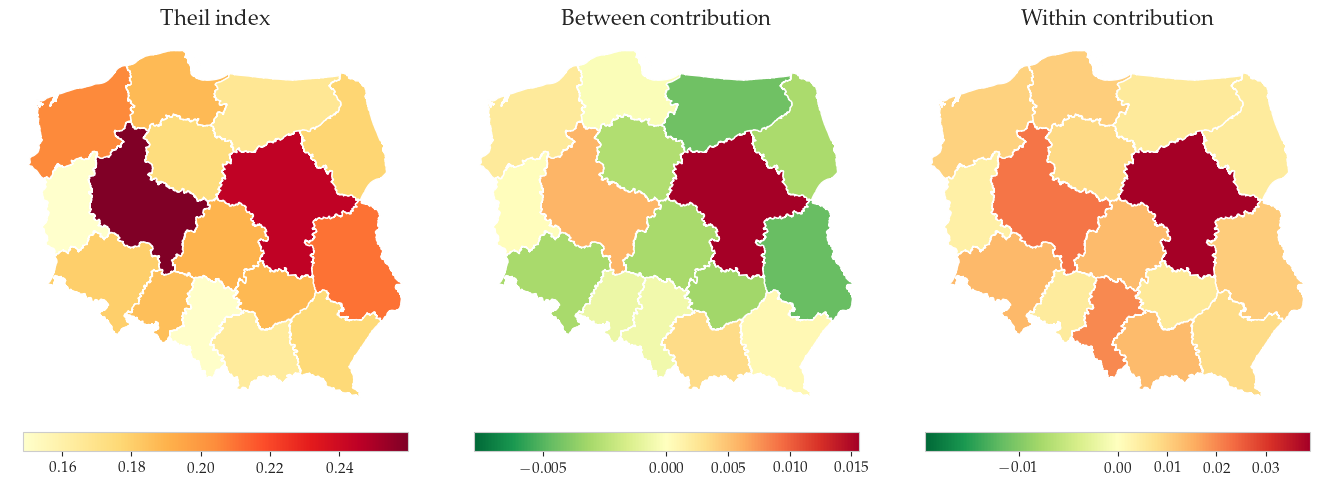

In [38]:
# ── Map: Theil index & contributions — LIS only (1999) ───────────────────────
YEAR = 1999

# LIS: regional panel for Theil index per voivodeship
lis_reg = lis_voiv_a.regional_panel(metrics=['theil'], region_id_col='region_id')
lis_reg = lis_reg[lis_reg['year'] == YEAR].copy()
lis_reg['region_id'] = lis_reg['region_id'].astype(str).str.zfill(7)
# LIS contributions
lis_ctr = lis_voiv_a.theil_contributions(YEAR, region_id_col='region_id')
lis_ctr['region_id'] = lis_ctr['region_id'].astype(str).str.zfill(7)

# Plot definitions: (data, col, label, cmap, diverging)
plot_defs = [
    (lis_reg, 'theil',                'Theil index',          'YlOrRd',   False),
    (lis_ctr, 'between_contribution', 'Between contribution', 'RdYlGn_r', True),
    (lis_ctr, 'within_contribution',  'Within contribution',  'RdYlGn_r', True),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.subplots_adjust(wspace=-1)

for col, (data, val_col, label, cmap_name, diverging) in enumerate(plot_defs):
    vals = data.set_index('region_id')[val_col]

    if diverging:
        vabs = max(abs(vals.min()), abs(vals.max()))
        norm = mpl.colors.TwoSlopeNorm(vmin=-vabs * 0.5, vcenter=0, vmax=vabs)
    else:
        norm = mpl.colors.Normalize(vmin=vals.min(), vmax=vals.max())
    cmap_map = mpl.colormaps[cmap_name]

    gdf = region_gdf.copy()
    gdf['value'] = gdf['teryt_id'].map(vals)
    gdf.plot(column='value', ax=axes[col], legend=False, cmap=cmap_map, norm=norm)
    axes[col].set_title(f'{label}', fontsize=16)
    axes[col].axis('off')

    sm = plt.cm.ScalarMappable(cmap=cmap_map, norm=norm)
    fig.colorbar(sm, ax=axes[col], orientation='horizontal', fraction=0.046, pad=0.04)

plt.savefig(PLOT_ROOT / f"theil_contributions_map_lis_{YEAR}.png", bbox_inches='tight')
plt.show()

**Theil decomposition by voivodeship — interpretation (1999–2017).**

The Theil T index is *exactly* decomposable: each voivodeship's contribution to national inequality has two additive parts:

$$T = \sum_g \underbrace{s_g \ln\!\left(\frac{\mu_g}{\mu}\right)}_{\text{between}_g} + \sum_g \underbrace{s_g \, T_g}_{\text{within}_g}$$

where $s_g = \frac{\sum_{i \in g} w_i y_i}{\sum_i w_i y_i}$ is the *income share* (not population share) of voivodeship $g$.

Key findings (1999–2017):

- **Mazowieckie (Warsaw region)** consistently contributes the most to total inequality — both via high *within-group* dispersion and a large positive *between-group* term (mean income well above the national average).
- Other economically significant voivodeships (Śląskie, Wielkopolskie, Małopolskie, Dolnośląskie) also have substantial contributions, mainly from the within component.
- Poorer, eastern voivodeships (Podkarpackie, Lubelskie, Podlaskie) can show *negative* between-group contributions ($\mu_g < \mu$, so $\ln(\mu_g/\mu) < 0$).
- Both CBOS and LIS paint a broadly consistent picture across the new 16-voivodeship administrative structure.
- The between-group inequality component captures the growing Warsaw–periphery divide over the transition and EU accession periods.